# Old with possible multi counting

/tmp/ipykernel_544845/528374411.py:103: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/tmp/ipykernel_544845/528374411.py:110: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/tmp/ipykernel_544845/528374411.py:117: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


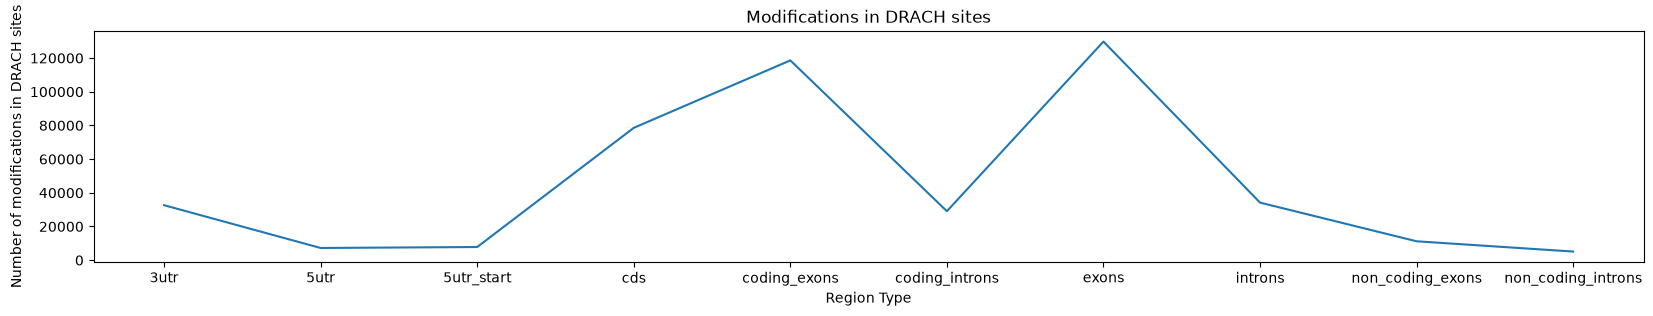

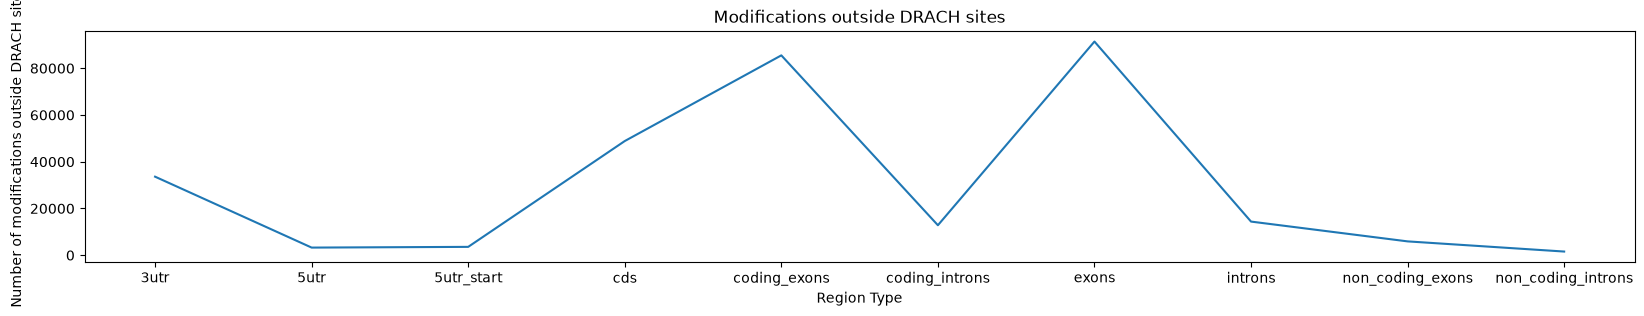

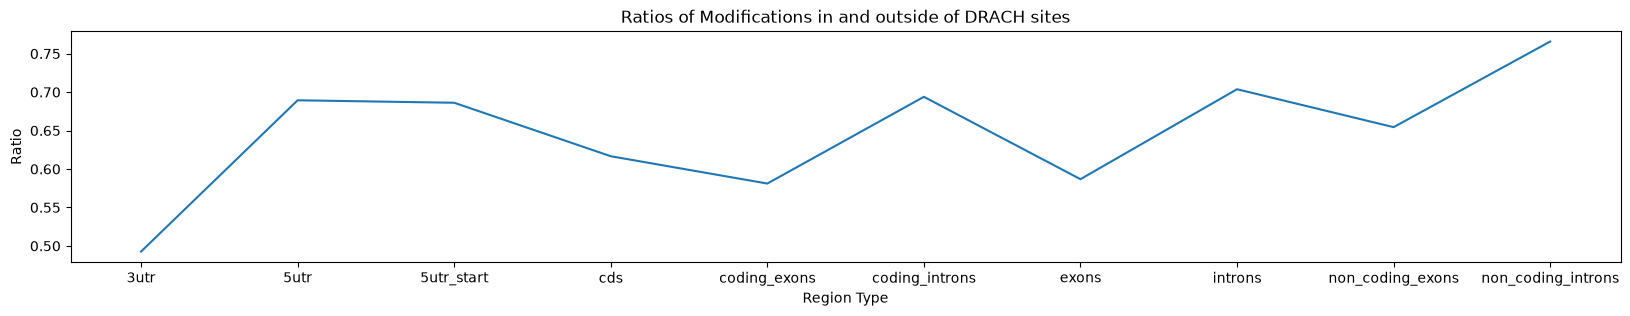

In [3]:
from fasta import FASTA
from src.util import load_region_modifications
from src.files.files import get_files
import matplotlib.pyplot as plt

drach_site_counts = {}
non_drach_site_counts = {}

def is_drach_positive(sequence, position):
    if position < 2 or position > len(sequence) - 3:
        return False

    if not sequence[position - 2] in ["A", "G", "U"]:
        return False

    if not sequence[position - 1] in ["A", "G"]:
        return False

    if sequence[position] != "A":
        print("modification site is not A")

    if sequence[position + 1] != "C":
        return False

    if not sequence[position + 2] in ["A", "C", "U"]:
        return False
    
    return True

def is_drach_negative(sequence, position):
    if position < 2 or position > len(sequence) - 3:
        return False

    if not sequence[position - 2] in ["U", "G", "A"]:
        return False

    if sequence[position - 1] != "G":
        return False

    if sequence[position] != "A":
        print("modification site is not A")

    if not sequence[position + 1] in ["U", "C"]:
        return False

    if not sequence[position + 2] in ["U", "C", "A"]:
        return False
    
    return True

def is_drach(sequence, strand, position):
    if strand == "+":
        return is_drach_positive(sequence, position)
    else:
        return is_drach_negative(sequence, position)

for key, file in get_files().get_assembled_region_fasta_files().get_files_dict().items():
    drach_site_counts[key] = 0
    non_drach_site_counts[key] = 0
    
    regions = load_region_modifications(get_files().get_assembled_region_local_intersects_assembled_files().get_files_dict()[key])
    
    file.open_or_recompute()
    fasta_file = FASTA(file.get_possibly_gzip_path())

    for entry in fasta_file:
        region_name = entry.name[:entry.name.find(":")]

        if not region_name in regions or len(regions[region_name].modifications) == 0:
            continue
        
        strand = None

        sequence = str(entry.seq).upper().replace("T", "U")
        
        if entry.name.endswith("(+)"):
            strand = "+"
        elif entry.name.endswith("(-)"):
            strand = "-"

        modifications = regions[region_name].modifications

        for modification in modifications:
            if is_drach(sequence, strand, modification):
                drach_site_counts[key] += 1
            else:
                non_drach_site_counts[key] += 1

drach_non_drach_ratios = {}

for key in drach_site_counts.keys():
    drach_site_count = drach_site_counts[key]
    non_drach_site_count = non_drach_site_counts[key]
    total_count = drach_site_count + non_drach_site_count
    
    drach_non_drach_ratios[key] =  drach_site_count / total_count 

fig, axs = plt.subplots(figsize=(20, 3))
axs.plot(drach_site_counts.keys(), drach_site_counts.values())
axs.set_title("Modifications in DRACH sites")
axs.set_xlabel("Region Type")
axs.set_ylabel("Number of modifications in DRACH sites")
fig.show()

fig, axs = plt.subplots(figsize=(20, 3))
axs.plot(non_drach_site_counts.keys(), non_drach_site_counts.values())
axs.set_title("Modifications outside DRACH sites")
axs.set_xlabel("Region Type")
axs.set_ylabel("Number of modifications outside DRACH sites")
fig.show()

fig, axs = plt.subplots(figsize=(20, 3))
axs.plot(drach_non_drach_ratios.keys(), drach_non_drach_ratios.values())
axs.set_title("Ratios of Modifications in and outside of DRACH sites")
axs.set_xlabel("Region Type")
axs.set_ylabel("Ratio")
fig.show()


In [10]:
import gzip
import csv
import re
from fasta import FASTA
from src.files.files import get_files
from collections import defaultdict

# D = A, G, U
# R = A, G
# A = A
# C = C
# H = A, C, U

drach_options = ["UAACA", "UAACC", "UAACU", "UGACA", "UGACC", "UGACU"]
rrach_options = ["AAACA", "AAACC", "AAACU", "AGACA", "AGACC", "AGACU", "GAACA", "GAACC", "GAACU", "GGACA", "GGACC", "GGACU"]

complementations = str.maketrans({"A": "U", "U": "A", "G": "C", "C": "G"})

neg_drach_options = [option[::-1].translate(complementations) for option in drach_options]
neg_rrach_options = [option[::-1].translate(complementations) for option in rrach_options]

get_files().get_renamed_files().get_genome_file().open_or_recompute()

file = FASTA(get_files().get_renamed_files().get_genome_file().get_possibly_gzip_path())

modification_positions = {}
neg_modification_positions = {}

with get_files().get_renamed_files().get_modifications_file().open_or_recompute() as modification_file:
    modification_csv_file = csv.reader(modification_file, delimiter="\t")

    for modification in modification_csv_file:
        if modification[5] == ".":
            continue

        if modification[5] == "+":
            modification_positions[int(modification[1])] = True
        else:
            neg_modification_positions[int(modification[1])] = True
        

drach_stats = { "unmodified": defaultdict(int), "modified": defaultdict(int) }
rrach_stats = { "unmodified": defaultdict(int), "modified": defaultdict(int) }

neg_drach_stats = { "unmodified": defaultdict(int), "modified": defaultdict(int) }
neg_rrach_stats = { "unmodified": defaultdict(int), "modified": defaultdict(int) }

modifications_in_drach = 0
modifications_in_rrach = 0
modifications_outside_motif = 0

neg_modifications_in_drach = 0
neg_modifications_in_rrach = 0
neg_modifications_outside_motif = 0

for entry in file:
    rna_seq = str(entry.seq).upper().replace("T", "U")

    for window_start in range(len(rna_seq) - 5):
        window = rna_seq[window_start:window_start+5]

        window_modification_position = window_start + 2
        
        if window in rrach_options:
            if window_modification_position in modification_positions:
                drach_stats["modified"][window] += 1
                rrach_stats["modified"][window] += 1
            else:
                drach_stats["unmodified"][window] += 1
                rrach_stats["unmodified"][window] += 1
                
        if window in drach_options:
            if window_modification_position in modification_positions:
                drach_stats["modified"][window] += 1
            else:
                drach_stats["unmodified"][window] += 1
                
        if window in neg_rrach_options:
            if window_modification_position in neg_modification_positions:
                neg_drach_stats["modified"][window] += 1
                neg_rrach_stats["modified"][window] += 1
            else:
                neg_drach_stats["unmodified"][window] += 1
                neg_rrach_stats["unmodified"][window] += 1
                
        if window in neg_drach_options:
            if window_modification_position in neg_modification_positions:
                neg_drach_stats["modified"][window] += 1
            else:
                neg_drach_stats["unmodified"][window] += 1

    for modification_position in modification_positions.keys():
        if modification_position < 2 or modification_position > len(rna_seq) - 3:
            modifications_outside_motif += 1
            continue
        
        modification_window = rna_seq[modification_position - 2:modification_position + 3]

        if modification_window in rrach_options:
            modifications_in_drach += 1
            modifications_in_rrach += 1
            continue
        if modification_window in drach_options:
            modifications_in_drach += 1
            continue
        
        modifications_outside_motif += 1
        
    for neg_modification_position in neg_modification_positions.keys():
        if neg_modification_position < 2 or neg_modification_position > len(rna_seq) - 3:
            neg_modifications_outside_motif += 1

        neg_modification_window = rna_seq[neg_modification_position - 2:neg_modification_position + 3]

        if neg_modification_window in neg_rrach_options:
            neg_modifications_in_drach += 1
            neg_modifications_in_rrach += 1
            continue
        if neg_modification_window in neg_drach_options:
            neg_modifications_in_drach += 1
            continue
        
        neg_modifications_outside_motif += 1

print("done")

done


In [11]:
drach_stats["total"] = defaultdict(int)
rrach_stats["total"] = defaultdict(int)

neg_drach_stats["total"] = defaultdict(int)
neg_rrach_stats["total"] = defaultdict(int)

total_drach_stats = { "unmodified": defaultdict(int), "modified": defaultdict(int), "total": defaultdict(int) }
total_rrach_stats = { "unmodified": defaultdict(int), "modified": defaultdict(int), "total": defaultdict(int) }

total_total_stats = { "unmodified": defaultdict(int), "modified": defaultdict(int), "total": defaultdict(int) }

total_modifications = 0
total_neg_modifications = 0

total_modifications_in_drach = 0
total_modifications_in_rrach = 0
total_modifications_outside_motif = 0
total_total_modifications = 0

for key, stat in drach_stats["unmodified"].items():
    drach_stats["total"][key] = drach_stats["unmodified"][key] + drach_stats["modified"][key]

for key, stat in rrach_stats["unmodified"].items():
    rrach_stats["total"][key] = rrach_stats["unmodified"][key] + rrach_stats["modified"][key]

for key, stat in neg_drach_stats["unmodified"].items():
    neg_drach_stats["total"][key] = neg_drach_stats["unmodified"][key] + neg_drach_stats["modified"][key]

for key, stat in neg_rrach_stats["unmodified"].items():
    neg_rrach_stats["total"][key] = neg_rrach_stats["unmodified"][key] + neg_rrach_stats["modified"][key]

drach_stats["unmodified"]["total"] = sum(drach_stats["unmodified"].values())
drach_stats["modified"]["total"] = sum(drach_stats["modified"].values())
drach_stats["total"]["total"] = sum(drach_stats["total"].values())

rrach_stats["unmodified"]["total"] = sum(rrach_stats["unmodified"].values())
rrach_stats["modified"]["total"] = sum(rrach_stats["modified"].values())
rrach_stats["total"]["total"] = sum(rrach_stats["total"].values())

neg_drach_stats["unmodified"]["total"] = sum(neg_drach_stats["unmodified"].values())
neg_drach_stats["modified"]["total"] = sum(neg_drach_stats["modified"].values())
neg_drach_stats["total"]["total"] = sum(neg_drach_stats["total"].values())

neg_rrach_stats["unmodified"]["total"] = sum(neg_rrach_stats["unmodified"].values())
neg_rrach_stats["modified"]["total"] = sum(neg_rrach_stats["modified"].values())
neg_rrach_stats["total"]["total"] = sum(neg_rrach_stats["total"].values())

for key, stat in drach_stats["unmodified"].items():
    total_drach_stats["unmodified"][key] = drach_stats["unmodified"][key] + neg_drach_stats["unmodified"][key]

for key, stat in drach_stats["modified"].items():
    total_drach_stats["modified"][key] = drach_stats["modified"][key] + neg_drach_stats["modified"][key]

for key, stat in drach_stats["total"].items():
    total_drach_stats["total"][key] = drach_stats["total"][key] + neg_drach_stats["total"][key]

for key, stat in rrach_stats["unmodified"].items():
    total_rrach_stats["unmodified"][key] = rrach_stats["unmodified"][key] + neg_rrach_stats["unmodified"][key]

for key, stat in rrach_stats["modified"].items():
    total_rrach_stats["modified"][key] = rrach_stats["modified"][key] + neg_rrach_stats["modified"][key]

for key, stat in rrach_stats["total"].items():
    total_rrach_stats["total"][key] = rrach_stats["total"][key] + neg_rrach_stats["total"][key]

for key, stat in drach_stats["unmodified"].items():
    total_total_stats["unmodified"][key] = total_drach_stats["unmodified"][key] + total_rrach_stats["unmodified"][key]

for key, stat in drach_stats["modified"].items():
    total_total_stats["modified"][key] = total_drach_stats["modified"][key] + total_rrach_stats["modified"][key]

for key, stat in drach_stats["total"].items():
    total_total_stats["total"][key] = total_drach_stats["total"][key] + total_rrach_stats["total"][key]

total_modifications = modifications_in_drach + modifications_in_rrach
total_neg_modifications = neg_modifications_in_drach + neg_modifications_in_rrach

total_modifications_in_drach = modifications_in_drach + neg_modifications_in_drach
total_modifications_in_rrach = modifications_in_rrach + neg_modifications_in_rrach
total_modifications_outside_motif = modifications_outside_motif + neg_modifications_outside_motif

total_total_modifications = total_modifications_in_drach + total_total_modifications

print("done")

done


In [13]:
print("drach:", "unmodified", drach_stats["unmodified"]["total"], "modified", drach_stats["modified"]["total"], "total", drach_stats["total"]["total"])
print("rrach:", "unmodified", rrach_stats["unmodified"]["total"], "modified", rrach_stats["modified"]["total"], "total", rrach_stats["total"]["total"])
print("neg_drach:", "unmodified", neg_drach_stats["unmodified"]["total"], "modified", neg_drach_stats["modified"]["total"], "total", neg_drach_stats["total"]["total"])
print("neg_rrach:", "unmodified", neg_rrach_stats["unmodified"]["total"], "modified", neg_rrach_stats["modified"]["total"], "total", neg_rrach_stats["total"]["total"])

print("total_drach:", "unmodified", total_drach_stats["unmodified"]["total"], "modified", total_drach_stats["modified"]["total"], "total", total_drach_stats["total"]["total"])
print("total_rrach:", "unmodified", total_rrach_stats["unmodified"]["total"], "modified", total_rrach_stats["modified"]["total"], "total", total_rrach_stats["total"]["total"])
print("total_total:", "unmodified", total_total_stats["unmodified"]["total"], "modified", total_total_stats["modified"]["total"], "total", total_total_stats["total"]["total"])

print("modifications", "outside motif", modifications_outside_motif, "in rrach", modifications_in_rrach, "in drach", modifications_in_drach)
print("neg modifications", "outside motif", neg_modifications_outside_motif, "in rrach", neg_modifications_in_rrach, "in drach", neg_modifications_in_drach)
print("total modifications", "outside motif", total_modifications_outside_motif, "in rrach", total_modifications_in_rrach, "in drach", total_modifications_in_drach)

drach: unmodified 2866921 modified 11017 total 2877938
rrach: unmodified 2015502 modified 10286 total 2025788
neg_drach: unmodified 2829824 modified 12555 total 2842379
neg_rrach: unmodified 1979788 modified 11784 total 1991572
total_drach: unmodified 5696745 modified 23572 total 5720317
total_rrach: unmodified 3995290 modified 22070 total 4017360
total_total: unmodified 9692035 modified 45642 total 9737677
modifications outside motif 2344 in rrach 10286 in drach 11017
neg modifications outside motif 2492 in rrach 11784 in drach 12555
total modifications outside motif 4836 in rrach 22070 in drach 23572
